In [45]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error



In [46]:
#importing dataset 

df = pd.read_csv(r"C:\Users\shrad\Downloads\india_personal_loan_default_risk_2026 - india_personal_loan_default_risk_2026.csv")

print("Original Dataset Shape :", df.shape)

print(
    "Missing CIBIL scores before removal:",
    df["cibil_score"].isnull().sum()
)

df = df.dropna(
    subset=["cibil_score"]
).copy()

print(
    "Missing CIBIL scores after removal:",
    df["cibil_score"].isnull().sum()
)

print("Dataset shape after removing missing CIBIL:", df.shape)


Original Dataset Shape : (25002, 25)
Missing CIBIL scores before removal: 2
Missing CIBIL scores after removal: 0
Dataset shape after removing missing CIBIL: (25000, 25)


In [47]:

features = [
    "age",
    "NEW_BANKCCTYEARS",
    "monthly_income_inr",
    "existing_loans_count",
    "NEW_EXISTING EMI",
    "credit_utilization_ratio_pct",
    "num_credit_inquiries_last_6m",
    "late_payments_last_12m",
    "employment_type"
]

x = df[features]
y = df["cibil_score"]

print("\nMissing values in x:")
print(x.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())


Missing values in x:
age                               0
NEW_BANKCCTYEARS                  0
monthly_income_inr                0
existing_loans_count              0
NEW_EXISTING EMI                  0
credit_utilization_ratio_pct      0
num_credit_inquiries_last_6m    250
late_payments_last_12m            0
employment_type                   0
dtype: int64

Missing values in y:
0


In [48]:
#DEFINING NUMERICAL & CATEGORIAL FEATURES 

numerical_features = [
    "age",
    "NEW_BANKCCTYEARS",
    "monthly_income_inr",
    "existing_loans_count",
    "NEW_EXISTING EMI",
    "credit_utilization_ratio_pct",
    "num_credit_inquiries_last_6m",
    "late_payments_last_12m"
]

categorical_features = [
    "employment_type"
]


#TRAIN X AND Y 
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size= 0.20, random_state= 42)

print("Training Data:", x_train.shape)
print("Testing Data:", x_test.shape)

Training Data: (20000, 9)
Testing Data: (5000, 9)


In [49]:
#NUMERICAL PREPROCESSING 

numerical_preprocessing = Pipeline([
    ( "impute",
       SimpleImputer(strategy="median")
       ),
       ("scaler",
        StandardScaler())
])

#CATEGORIAL PREPROCESSING
categorical_preprocessing = Pipeline([
    ("impute",
     SimpleImputer(strategy="most_frequent")),
     ("encode",
      OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("numerical",
     numerical_preprocessing,
     numerical_features),
     (
         "categorical",
         categorical_preprocessing,
         categorical_features
     )
])



In [50]:
#MODEL TRAINING

linear_model = Pipeline([
("Preprocessing", preprocessor),
("Model", LinearRegression())    
])

linear_model.fit(
    x_train, y_train
    )

linear_model_predict = linear_model.predict(x_test)


tree_model = Pipeline([
("Preprocessing", preprocessor),
("Model", DecisionTreeRegressor(random_state=42, max_depth=5))    
])

tree_model.fit(x_train, y_train)
tree_model_predict = tree_model.predict(x_test)


forest_model = Pipeline([
("Preprocessing", preprocessor),
("Model", RandomForestRegressor( n_estimators=200,
            random_state=42,
            max_depth=10,
            n_jobs=-1))    
])

forest_model.fit(
    x_train,
    y_train
)

forest_prediction = forest_model.predict(
    x_test
)


In [51]:
#MODEL EVALUATION

def evaluate_model(model_name, actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    print("\n" + model_name)
    print("-" * 40)

    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²  :", round(r2, 4))

    return mae, rmse, r2



In [52]:
#EVALUATE MODELS

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_model_predict
)

tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    tree_model_predict
)

forest_results = evaluate_model(
    "Random Forest",
    y_test,
    forest_prediction
)


#MODEL COMPARE TABLE 

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        linear_results[0],
        tree_results[0],
        forest_results[0]
    ],

    "RMSE": [
        linear_results[1],
        tree_results[1],
        forest_results[1]
    ],

    "R2": [
        linear_results[2],
        tree_results[2],
        forest_results[2]
    ]
})


print("\nMODEL COMPARISON")
print(results)


Linear Regression
----------------------------------------
MAE : 29.44
RMSE: 37.33
R²  : 0.6525

Decision Tree
----------------------------------------
MAE : 35.3
RMSE: 44.19
R²  : 0.513

Random Forest
----------------------------------------
MAE : 29.93
RMSE: 37.78
R²  : 0.6441

MODEL COMPARISON
               Model        MAE       RMSE        R2
0  Linear Regression  29.438281  37.327341  0.652527
1      Decision Tree  35.296734  44.190249  0.513010
2      Random Forest  29.930801  37.775564  0.644132


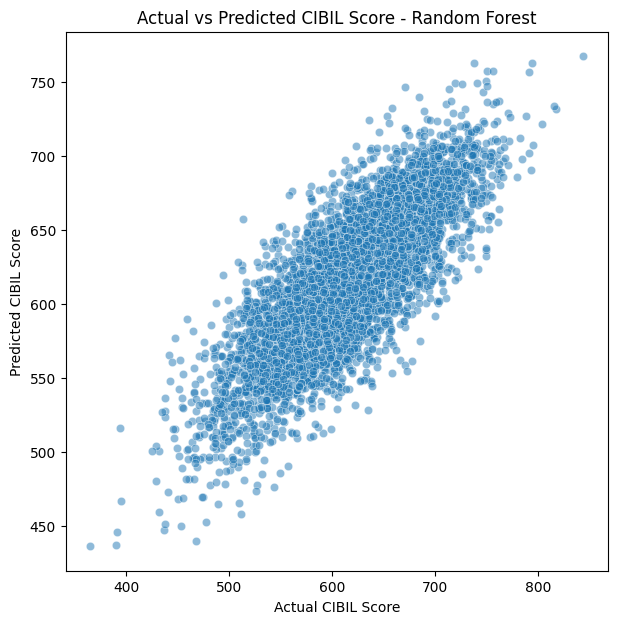


FEATURE IMPORTANCE
                                              Feature  Importance
5             numerical__credit_utilization_ratio_pct    0.526098
7                   numerical__late_payments_last_12m    0.213316
4                         numerical__NEW_EXISTING EMI    0.098687
1                         numerical__NEW_BANKCCTYEARS    0.070600
2                       numerical__monthly_income_inr    0.051558
6             numerical__num_credit_inquiries_last_6m    0.014581
0                                      numerical__age    0.012184
3                     numerical__existing_loans_count    0.006920
11    categorical__employment_type_Salaried - Private    0.001377
9   categorical__employment_type_Salaried - Govern...    0.001317
8         categorical__employment_type_Business Owner    0.001281
12  categorical__employment_type_Self-Employed Pro...    0.001086
10        categorical__employment_type_Salaried - PSU    0.000995


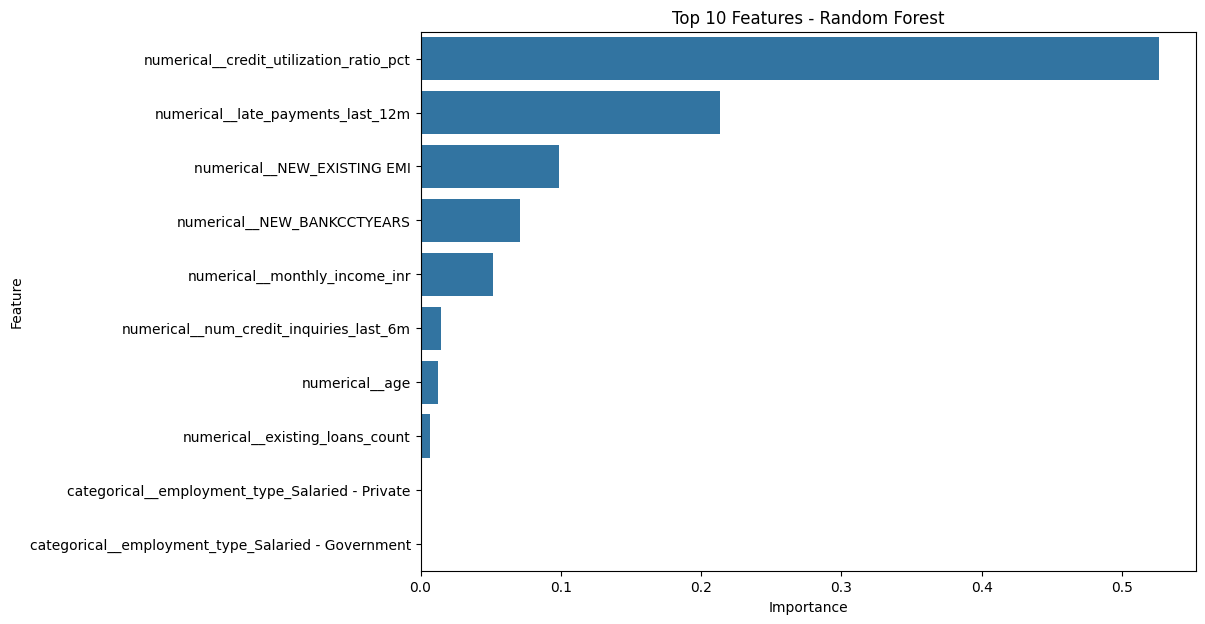

In [53]:
#ACTUAL VS PREDICT


plt.figure(figsize=(7,7))

sns.scatterplot(
    x=y_test,
    y=forest_prediction,
    alpha=0.5
)

plt.xlabel("Actual CIBIL Score")
plt.ylabel("Predicted CIBIL Score")

plt.title(
    "Actual vs Predicted CIBIL Score - Random Forest"
)

plt.show()



#  RANDOM FOREST FEATURE IMPORTANCE


feature_names = forest_model.named_steps[
    "Preprocessing"
].get_feature_names_out()

importance_values = forest_model.named_steps[
    "Model"
].feature_importances_


feature_importance = pd.DataFrame({

    "Feature": feature_names,
    "Importance": importance_values

})


feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)


print("\nFEATURE IMPORTANCE")
print(feature_importance)


# TOP 10 FEATURE IMPORTANCE GRAPH

plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Features - Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [54]:
#USER INPUT 

print("\nEnter your details:")

age = float(input("Age: "))
bank_years = float(input("How many years have you had a bank account? "))
income = float(input("Monthly income (INR): "))
existing_loans = int(input("Number of existing loans: "))
existing_emi = float(input("Total monthly EMI (INR): "))

credit_card_balance = float(input("Total current credit card balance (INR): "))
credit_limit = float(input("Total credit card limit (INR): "))

credit_inquiries = int(input("Credit inquiries in last 6 months: "))
late_payments = int(input("Late payments in last 12 months: "))
employment = input("Employment type: ")

# Calculate Credit Utilization Ratio
if credit_limit > 0:
    credit_utilization = (credit_card_balance / credit_limit) * 100
else:
    credit_utilization = 0

# Create user data for prediction
user_data = pd.DataFrame({
    "age": [age],
    "NEW_BANKCCTYEARS": [bank_years],
    "monthly_income_inr": [income],
    "existing_loans_count": [existing_loans],
    "NEW_EXISTING EMI": [existing_emi],
    "credit_utilization_ratio_pct": [credit_utilization],
    "num_credit_inquiries_last_6m": [credit_inquiries],
    "late_payments_last_12m": [late_payments],
    "employment_type": [employment]
})

# Predict CIBIL
predicted_cibil = forest_model.predict(user_data)[0]

print("\n================================")
print(f"Credit Utilization Ratio: {credit_utilization:.2f}%")
print(f"Predicted CIBIL Score: {predicted_cibil:.2f}")
print("================================")




Enter your details:

Credit Utilization Ratio: 16.00%
Predicted CIBIL Score: 726.88
